# Lista III

## Regularyzacja zadanie na 3.0

Celem jest porownanie modeli bazowych z wersjami regularyzowanymi oraz znalezienie punktu, w ktorym model przestaje sie nadmiernie dopasowywac do zbioru treningowego.

## Przygotowanie danych

W raporcie wykorzystuję dwa zbiory danych, ponieważ poszczególne zadania dotyczą różnych typów problemów. Zbiór Telco Customer Churn służy do zadań klasyfikacyjnych, natomiast zbiór diamonds wykorzystuję w zadaniach regresyjnych, gdzie przewidywana jest wartość price.

Wszystkie porównania modeli oraz prezentowane metryki końcowe zostały obliczone na zbiorze testowym, który nie był wykorzystywany podczas treningu. Dzięki temu wyniki pokazują rzeczywistą zdolność modeli do uogólniania na niewidziane wcześniej dane.

In [1]:
from algorithms.regularization.linear_regularization_comparison import LinearRegularizationComparison
from algorithms.regularization.tree_regularization import TreeRegularizationComparison
from algorithms.bagging.tree_comparisions import ClassificationComparison
from algorithms.stacking.stacking_comparisions import StackingComparison
from algorithms.boosting.boosting_comparisions import BoostingComparison
from algorithms.experts.mixture_of_experts_comparisions import MixtureOfExpertsComparison
from experiments.reporting import (
    display_boosting_comparison,
    display_boosting_results,
    display_boosting_summary,
    display_classification_comparison,
    display_final_classification_summary,
    display_final_regression_summary,
    display_linear_regularization_comparison,
    display_linear_regularization_results,
    display_linear_regularization_summary,
    display_linear_regularization_weights,
    display_mixture_cluster_summary,
    display_mixture_global_comparison,
    display_mixture_model_comparison,
    display_stacking_diagnostics,
    display_stacking_metrics,
    display_stacking_vs_boosting,
    display_sweet_spot_summary,
    display_tree_regularization_comparison,
    display_tree_regularization_results,
    display_tree_regularization_summary,
    plot_boosting_comparison_report,
    plot_boosting_n_estimators_report,
    plot_classification_comparison_report,
    plot_final_classification_summary_report,
    plot_final_regression_summary_report,
    plot_linear_regularization_comparison_report,
    plot_linear_regularization_curves_report,
    plot_linear_weight_shrinkage_report,
    plot_linear_zero_weights_report,
    plot_mixture_clusters_report,
    plot_mixture_model_comparison_report,
    plot_stacking_diagnostics_report,
    plot_stacking_models_report,
    plot_stacking_vs_boosting_report,
    plot_tree_regularization_comparison_report,
    plot_tree_regularization_parameters_report,
)
from utils.file_operations import (
    load_diamonds_data,
    load_telco_data,
    split_diamonds_data,
    split_telco_data,
)
from utils.preprocessing import (
    encode_train_test_features,
    prepare_diamonds_data,
    prepare_linear_regularization_data,
    prepare_telco_data,
)

train_diamonds, test_diamonds = split_diamonds_data(load_diamonds_data())
train_telco, test_telco = split_telco_data(load_telco_data())

X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds = prepare_diamonds_data(
    train_diamonds, test_diamonds
)
X_train_telco, y_train_telco, X_test_telco, y_test_telco = prepare_telco_data(
    train_telco, test_telco
)

linear_data = prepare_linear_regularization_data(
    X_train_diamonds, y_train_diamonds, X_test_diamonds, y_test_diamonds
)
X_train_telco_encoded, X_test_telco_encoded = encode_train_test_features(X_train_telco, X_test_telco)


## Lasso i Ridge

Własna implementacja regresji liniowej opiera się na metodzie Gradient Descent. Punkt wyjścia stanowi klasyczna regresja liniowa, w której w każdej iteracji aktualizowane są wagi tak, aby zmniejszać błąd predykcji.
- W wersji Ridge do funkcji kosztu dodawana jest kara L2 (dodanie sumy wartości bezwzględnych wag (parametrów) pomnożonych przez współczynnik), która zmniejsza wartości wag, ale zwykle ich nie zeruje.
- W wersji Lasso dodawana jest kara L1 (dodanie sumy wartości bezwzględnych wag (parametrów) pomnożonych przez współczynnik), która nie tylko ogranicza wielkość wag, ale może również wyzerować część z nich, dzięki czemu model działa jednocześnie jako selektor cech.

W praktyce oznacza to, że Ridge stabilizuje model i ogranicza wpływ zbyt dużych współczynników, natomiast Lasso dodatkowo upraszcza model przez usuwanie części cech z rozwiązania. W tym zadaniu sprawdzałem różne wartości parametru alpha, aby znaleźć punkt, w którym regularyzacja poprawia jakość predykcji na zbiorze testowym.

In [2]:
linear_experiment = LinearRegularizationComparison().compare(**linear_data)

In [3]:
display_linear_regularization_results(linear_experiment)

,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Ridge,0.0000,1.965359e+06,2.261700e+06,20,0,0.1076,0.9164
1,Ridge,0.0000,1.965359e+06,2.261699e+06,20,0,0.1076,0.9164
2,Ridge,0.0000,1.965359e+06,2.261696e+06,20,0,0.1076,0.9164
3,Ridge,0.0000,1.965365e+06,2.261661e+06,20,0,0.1076,0.9164
4,Ridge,0.0001,1.965424e+06,2.261310e+06,20,0,0.1075,0.9161
5,Ridge,0.0010,1.966089e+06,2.257769e+06,20,0,0.1065,0.9134
6,Ridge,0.0100,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904
7,Ridge,0.1000,2.206637e+06,2.367584e+06,20,0,0.0588,0.7640
8,Ridge,1.0000,4.771878e+06,5.144019e+06,20,0,0.0415,0.3901
9,Ridge,10.0000,1.218241e+07,1.255831e+07,20,0,0.0096,0.0796


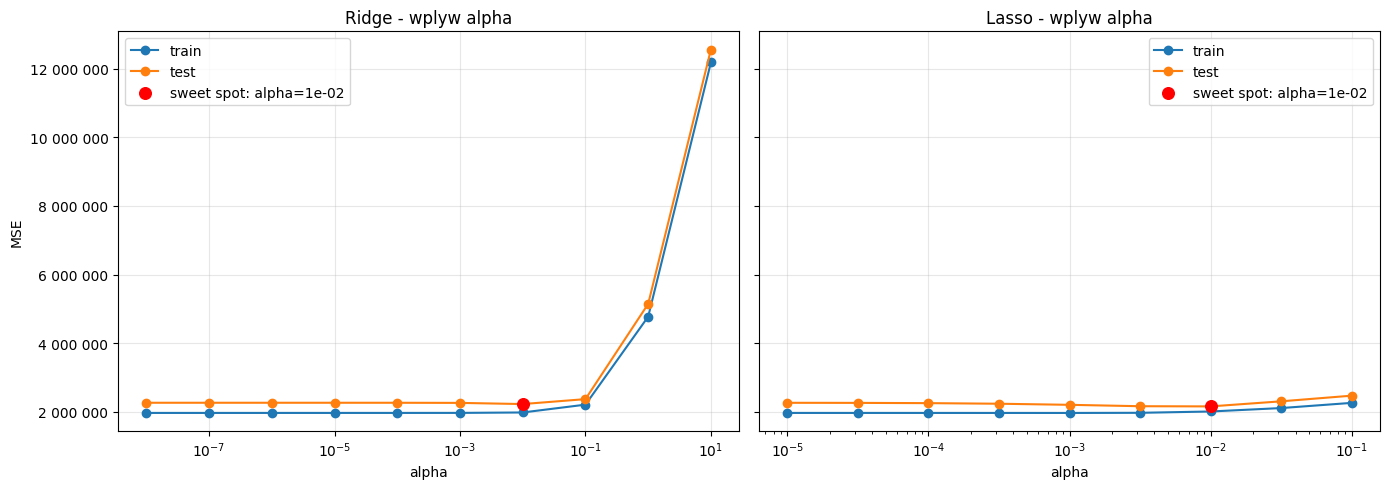

In [4]:
plot_linear_regularization_curves_report(linear_experiment)

Komentarz: na wykresie oraz z tabeli wynika, że minimum błędu testowego dla obu krzywych `wypada przy alpha = 0.01`, ale Lasso schodzi niżej niż Ridge. Dla większych wartości alpha regularyzacja staje się zbyt silna i błąd testowy zaczyna  rosnąć.

In [5]:
display_linear_regularization_summary(linear_experiment)

,model_type,alpha,train_mse,test_mse,nonzero_weights,zero_weights,mean_abs_weight,max_abs_weight
0,Lasso,0.01,2.007050e+06,2.155471e+06,11,9,0.0706,0.9039
1,Ridge,0.01,1.978396e+06,2.223667e+06,20,0,0.0973,0.8904


In [6]:
display_linear_regularization_comparison(linear_experiment)

,model,train_mse,test_mse,zero_weights
0,baseline GD,1965358.64,2261699.69,0
1,Ridge alpha=1e-02,1978396.17,2223666.92,0
2,Lasso alpha=1e-02,2007049.77,2155471.46,9


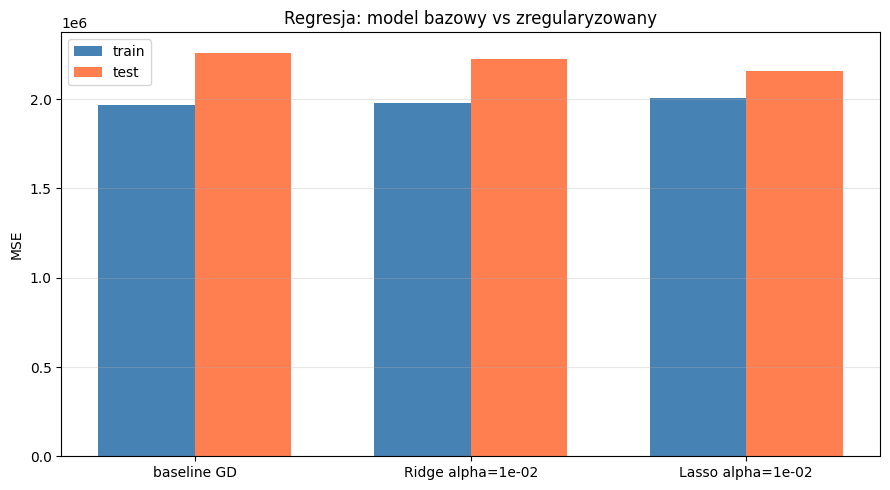

In [7]:
plot_linear_regularization_comparison_report(linear_experiment)

Komentarz:
- Powyższe tabele pokazują, że najlepszy model to Lasso alpha = 0.01 z test MSE = 2 155 471.46. Najlepszy Ridge przy tym samym alpha osiąga test MSE = 2 223 666.92, więc też poprawia wynik, ale słabiej niż Lasso. Baseline GD miał test MSE = 2 261 699.69, Ridge obniżył je o 38 032, a Lasso o 106 227
- Błąd treningowy lekko rośnie względem modelu bazowego, ale w zamian spada błąd testowy, czyli model lepiej generalizuje na niewidziane dane.

In [8]:
display_linear_regularization_weights(linear_experiment)

,feature,baseline_abs_weight,ridge_abs_weight,lasso_abs_weight,lasso_zero
0,carat,0.9164,0.8904,0.9039,False
1,carat^2,0.3525,0.2950,0.2317,False
2,carat^3,0.3263,0.2190,0.2406,False
3,carat^4,0.1826,0.1696,0.0000,True
4,carat^5,0.0696,0.0825,0.0000,True
5,carat^6,0.0052,0.0249,0.0000,True
6,carat^7,0.0181,0.0019,0.0000,True
7,carat^8,0.0250,0.0137,0.0000,True
8,carat^9,0.0256,0.0185,0.0000,True
9,carat^10,0.0244,0.0203,0.0000,True


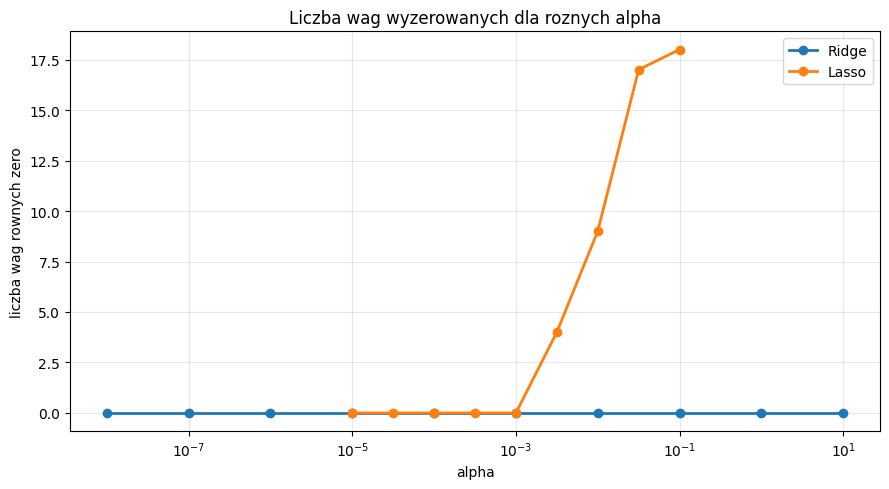

In [9]:
plot_linear_zero_weights_report(linear_experiment)

Komentarz:
- tabela wag pokazuje, że Lasso zaczyna zerować współczynniki już od składników około carat^4 wzwyż. Wyzerował łącznie 9 współczynników. Ridge również zmniejsza wagi wyższych potęg, ale nie eliminuje żadnej cechy całkowicie.
 - wykres zerowanych wag to potwierdza . Dla najlepszego modelu Lasso, czyli przy alpha = 0.01, wyzerowanych zostało 9 współczynników, natomiast Ridge dla wszystkich testowanych wartości alpha utrzymywał liczbę zer równą 0.

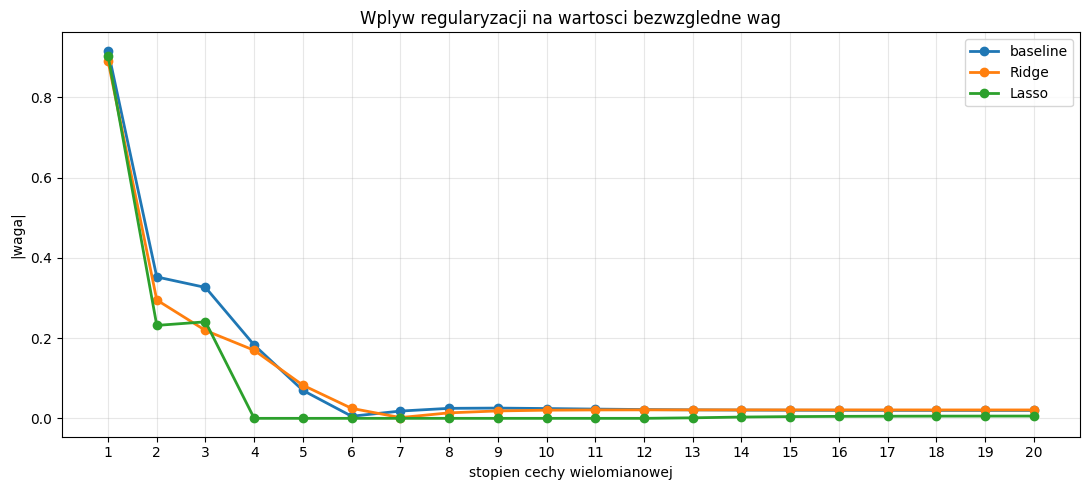

In [10]:
plot_linear_weight_shrinkage_report(linear_experiment)

Komentarz: na wykresie zmian wartości współczynników widać, że najwyższe potęgi wielomianu są najbardziej niestabilne i to właśnie je regularyzacja tłumi najmocniej. Lasso robi to skokowo przez wyzerowanie części wag, a Ridge wygładza je bardziej stopniowo

#### Wniosek

Podsumowując Ridge zmniejsza wartości współczynników, ale zachowuje wszystkie cechy w modelu. Lasso wyzerowało 9 wag, co potwierdza, że działa nie tylko jako mechanizm ograniczający overfitting, ale również jako prosty selektor cech.

## Regularyzacja drzewa decyzyjnego

W przypadku drzewa decyzyjnego regularyzacja nie polega na dodaniu kary do funkcji kosztu, lecz na ograniczeniu struktury modelu. Parametry takie jak min_samples_split (minimalna liczba próbek potrzebna aby węzeł był podzielone), min_samples_leaf (minimalna liczba próbek w każdym liściu) i max_features (ile cech wolno rozważyc podczas szukania najlepszego podziału) kontrolują, jak łatwo drzewo może tworzyć kolejne podziały oraz jak szczegółowo dopasowuje się do danych treningowych. Im mniej ograniczeń, tym większe ryzyko nadmiernego dopasowania.

W tym eksperymencie punktem odniesienia było drzewo bazowe, które praktycznie idealnie dopasowywało się do zbioru treningowego, ale wyraźnie gorzej generalizowało na zbiorze testowym. Następnie sprawdzałem, jak zmiana parametrów strukturalnych wpływa na błąd treningowy i testowy.

In [11]:
tree_experiment = TreeRegularizationComparison().compare(
    X_train_telco_encoded, y_train_telco, X_test_telco_encoded, y_test_telco
)

In [12]:
display_tree_regularization_results(tree_experiment)
display_tree_regularization_summary(tree_experiment)

,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,2,2,True,0.0020,0.2711
1,min_samples_split,5,5,False,0.0410,0.2704
2,min_samples_split,10,10,False,0.0788,0.2654
3,min_samples_split,20,20,False,0.1141,0.2463
4,min_samples_split,40,40,False,0.1479,0.2321
5,min_samples_split,80,80,False,0.1690,0.2207
6,min_samples_split,120,120,False,0.1823,0.2129
7,min_samples_split,200,200,False,0.1919,0.1994
8,min_samples_split,400,400,False,0.1972,0.2016
9,min_samples_leaf,1,1,True,0.0020,0.2711


,parameter,value,label,is_default,train_error,test_error
0,min_samples_split,200,200,False,0.1919,0.1994
1,min_samples_leaf,120,120,False,0.1972,0.2016
2,max_features,0.5,0.5,False,0.0020,0.2718


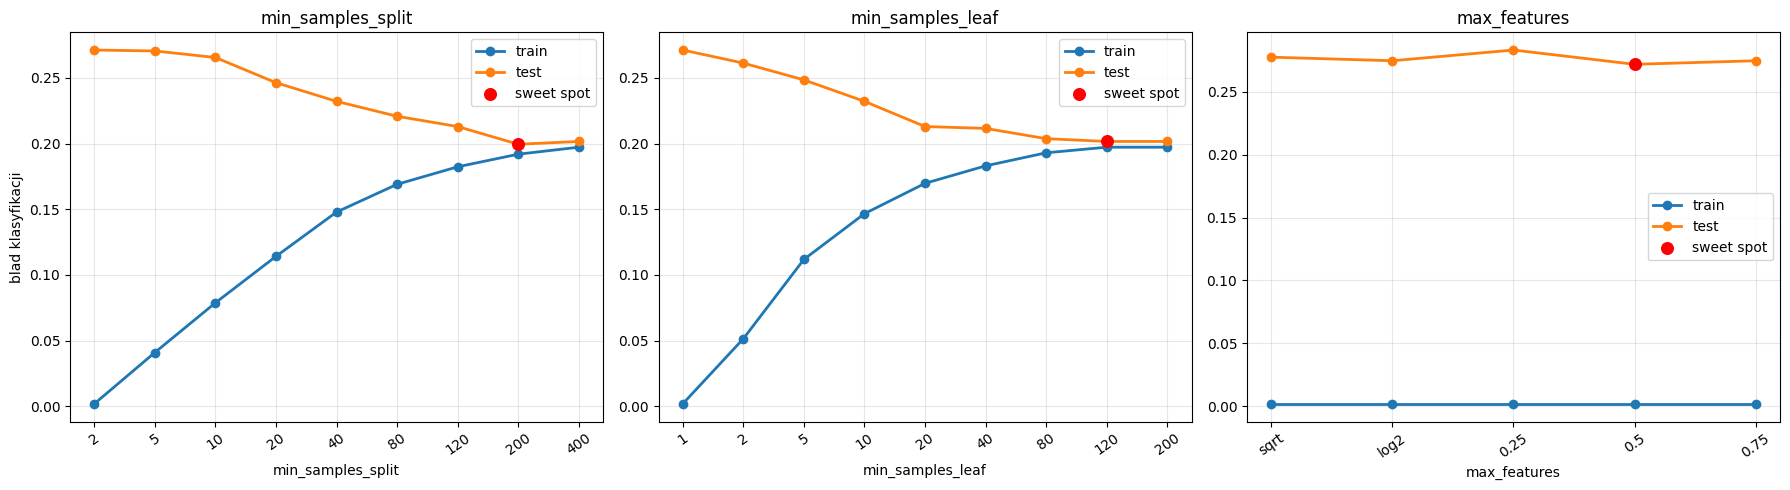

In [13]:
plot_tree_regularization_parameters_report(tree_experiment)

Komentarz: 
- wykres parametrów dobrze pokazuje, że ograniczenia związane z liczbą próbek w węzłach wyraźnie zmniejszają overfitting. Dla max_features krzywe train/test pozostają prawie w tym samym miejscu co model bazowy, więc ten parametr nie był tu kluczowy.
- dokładniejsze dane z powyżsej tabeli dla drzewa pokazuje również, że najskuteczniejsze było zwiększenie min_samples_split do 200, co dało test_error = 0.1994. min_samples_leaf = 120 też działa dobrze (0.2016), natomiast samo max_features = 0.5 praktycznie nie poprawia wyniku (0.2718).

In [14]:
display_tree_regularization_comparison(tree_experiment)

,model,train_error,test_error
0,baseline tree,0.0020,0.2711
1,min_samples_split=200,0.1919,0.1994


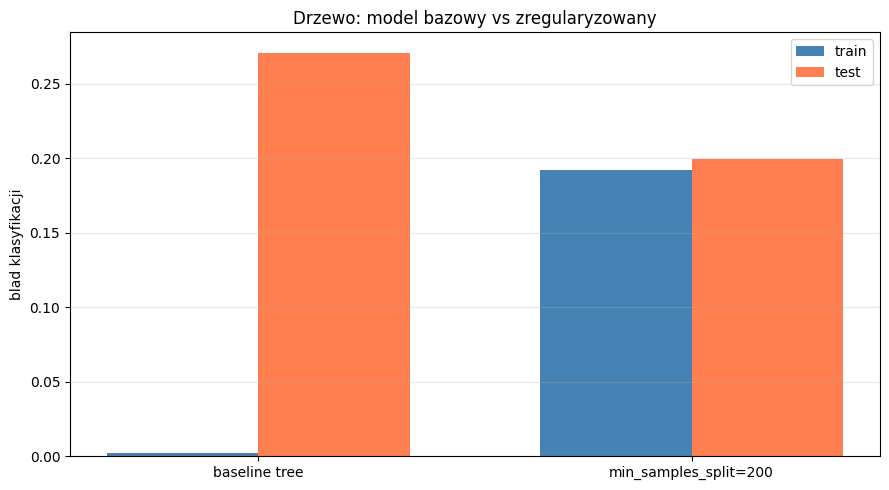

In [15]:
plot_tree_regularization_comparison_report(tree_experiment)

Komentarz: 
- wykres bazowego i zregularyzowanego drzewa pokazuje klasyczny kompromis bias-variance. Baseline tree pokazuje overfitting, zapamiętało idealnie dane treningowe, ale radzi sobie słabiej na nowych danych. Natiomiast dla drzewa zregularyzowane train error wzrósł bardzo mocno,
test error spadł. To jest dokładnie to, czego oczekujemy po dobrej regularyzacji.
- Z tabeli mamy, że Baseline tree miał train_error = 0.0020 i test_error = 0.2711, a po regularyzacji dostajemy train_error = 0.1919 i test_error = 0.1994 (spadek o 0.0717), czyli mniej przeuczenia i lepszy wynik testowy

#### Wniosek
Najlepszy wynik uzyskało drzewo z parametrem min_samples_split = 200, dla którego test_error = 0.1994. Dla porównania model bazowy miał test_error = 0.2711, przy bardzo niskim train_error = 0.0020. To jest typowy objaw overfittingu: model niemal perfekcyjnie zapamiętuje dane treningowe, ale gorzej radzi sobie z nowymi przykładami.

Regularyzacja zwiększyła błąd treningowy, ale jednocześnie wyraźnie obniżyła błąd testowy. Oznacza to, że ograniczenie swobody drzewa poprawiło jego zdolność do uogólniania. Najsilniejszy efekt dało zwiększenie min_samples_split, natomiast sam parametr max_features nie poprawił wyników tak wyraźnie jak ograniczenia liczby próbek w węzłach.

## Zadanie na 3.5
## Bagging oraz porównanie Decision Tree i Random Forest

Bagging jest metodą zespołową polegającą na uczeniu wielu niezależnych drzew decyzyjnych na różnych próbkach bootstrapowych utworzonych ze zbioru treningowego. Każda próbka bootstrapowa powstaje poprzez losowanie obserwacji ze zwracaniem, dzięki czemu poszczególne drzewa uczą się na nieco innych danych. W fazie predykcji końcowa decyzja wyznaczana jest poprzez głosowanie większościowe wszystkich drzew.

Głównym celem baggingu jest redukcja wariancji pojedynczego drzewa decyzyjnego. Drzewa decyzyjne należą do modeli niestabilnych – niewielka zmiana danych treningowych może prowadzić do powstania zupełnie innej struktury drzewa. Uśrednienie predykcji wielu drzew pozwala ograniczyć wpływ przypadkowych fluktuacji danych, co zwykle przekłada się na lepszą zdolność generalizacji oraz wyższą skuteczność na zbiorze testowym.

Random Forest stanowi rozszerzenie baggingu. Oprócz losowania próbek treningowych wprowadza również losowanie podzbioru cech rozważanych przy każdym podziale drzewa. Dzięki temu drzewa są mniej podobne do siebie, a różnorodność całego zespołu jest jeszcze większa.

Losowanie ze zwracaniem odgrywa kluczową rolę w działaniu baggingu. Dzięki niemu każde drzewo otrzymuje nieco inny zbiór treningowy, co zwiększa różnorodność modeli składowych. Gdyby wszystkie drzewa były trenowane na identycznych danych, powstałyby bardzo podobne modele popełniające te same błędy, a korzyści wynikające z agregacji byłyby niewielkie.

In [16]:
decision_vs_random = ClassificationComparison()
comparison_df = decision_vs_random.compare(
    X_train=X_train_telco_encoded,
    X_test=X_test_telco_encoded,
    y_train=y_train_telco,
    y_test=y_test_telco,
)

In [17]:
display_classification_comparison(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7289,0.7317,0.7289,0.7302
1,Random Forest,0.7779,0.7655,0.7779,0.7688
2,Bagging,0.7779,0.7670,0.7779,0.7704


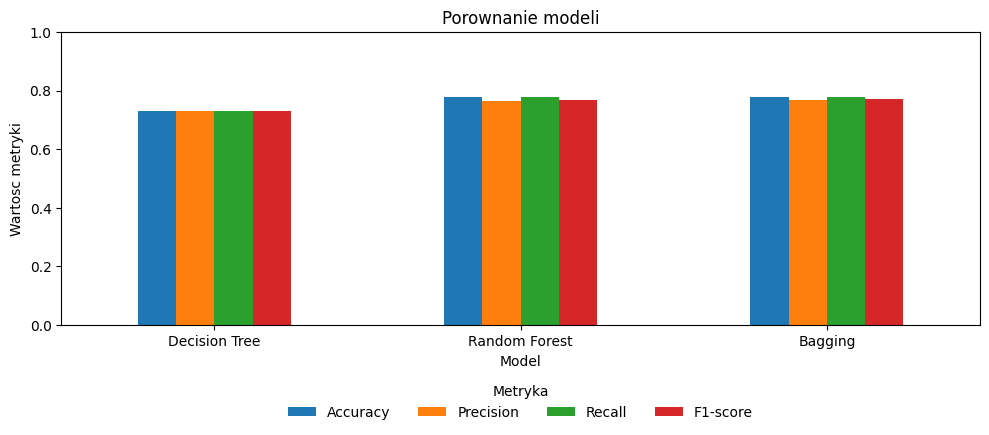

In [18]:
plot_classification_comparison_report(comparison_df)

Komentarz: 
- wykres potwierdza, że agregacja wielu drzew daje stabilną poprawę względem pojedynczego drzewa. Różnica między Random Forest i Bagging jest niewielka, ale oba modele utrzymują przewagę w każdej metryce.
- tabela klasyfikacyjna pokazuje, że najsłabszy jest pojedynczy Decision Tree, a oba modele zespołowe wypadają wyraźnie lepiej. Najlepszy wynik osiągnął Bagging (Accuracy = 0.7814, F1-score = 0.7747), nieznacznie wyprzedzając Random Forest (Accuracy = 0.7779, F1-score = 0.7688)
- Mimo że Random Forest wprowadza dodatkową losowość poprzez losowanie podzbioru cech przy każdym podziale drzewa, w analizowanym zbiorze danych nie przełożyło się to na poprawę jakości klasyfikacji. Prawdopodobnie większość cech była użyteczna, dlatego ograniczanie ich liczby podczas budowy drzew nie przyniosło korzyści. W rezultacie nieznacznie lepszy wynik osiągnął klasyczny Bagging.

#### Wniosek
Na podstawie uzyskanych wyników można zauważyć, że pojedyncze drzewo decyzyjne osiągnęło najsłabsze wartości wszystkich analizowanych metryk. Zarówno Random Forest, jak i własna implementacja Baggingu poprawiają Accuracy, Precision, Recall i F1-score, co potwierdza przewagę metod zespołowych nad pojedynczym drzewem.

W aktualnym eksperymencie minimalnie najlepszy okazał się Random Forest, który osiągnął Accuracy = 0.7779 i F1-score = 0.7688, podczas gdy Bagging uzyskał bardzo zbliżone Accuracy = 0.7736 i F1-score = 0.7668. Oznacza to, że mechanizm baggingu działa poprawnie i daje wyniki porównywalne z gotowym rozwiązaniem ze scikit-learn, ale w tym konkretnym przebiegu minimalna przewaga należy do lasu losowego.

## Zadanie na 4.0 Stacking

W tej części wykorzystuję własną implementację stackingu do problemu regresji na zbiorze diamonds oraz porównuje go z gradientBoostingiem. Na poziomie 0 działają trzy modele bazowe: DecisionTreeRegressor, RandomForestRegressor oraz ExtraTreesRegressor. Ich predykcje stają się wejściem dla meta-modelu Ridge, który uczy się, jak połączyć odpowiedzi modeli bazowych w jedną końcową predykcję ceny diamentu.

Implementacja działa dwuetapowo. Najpierw dla zbioru treningowego wyznaczane są predykcje out-of-fold modeli poziomu 0, a następnie na tych predykcjach uczony jest meta-model. Po tym kroku modele bazowe są jeszcze raz trenowane na całym zbiorze treningowym, aby można było użyć ich do predykcji na zbiorze testowym.

In [19]:
stacking_experiment = StackingComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)

In [20]:
display_stacking_metrics(stacking_experiment)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Decision Tree,811.2760,813.9943,1417.1171,1416.7711,0.8739,0.8737
1,Random Forest,100.9854,270.1552,206.4245,550.5685,0.9973,0.9809
2,Extra Trees,0.4957,269.0765,9.0716,555.3080,1.0000,0.9806
3,Stacking,42.2648,265.4705,83.6980,543.3274,0.9996,0.9814


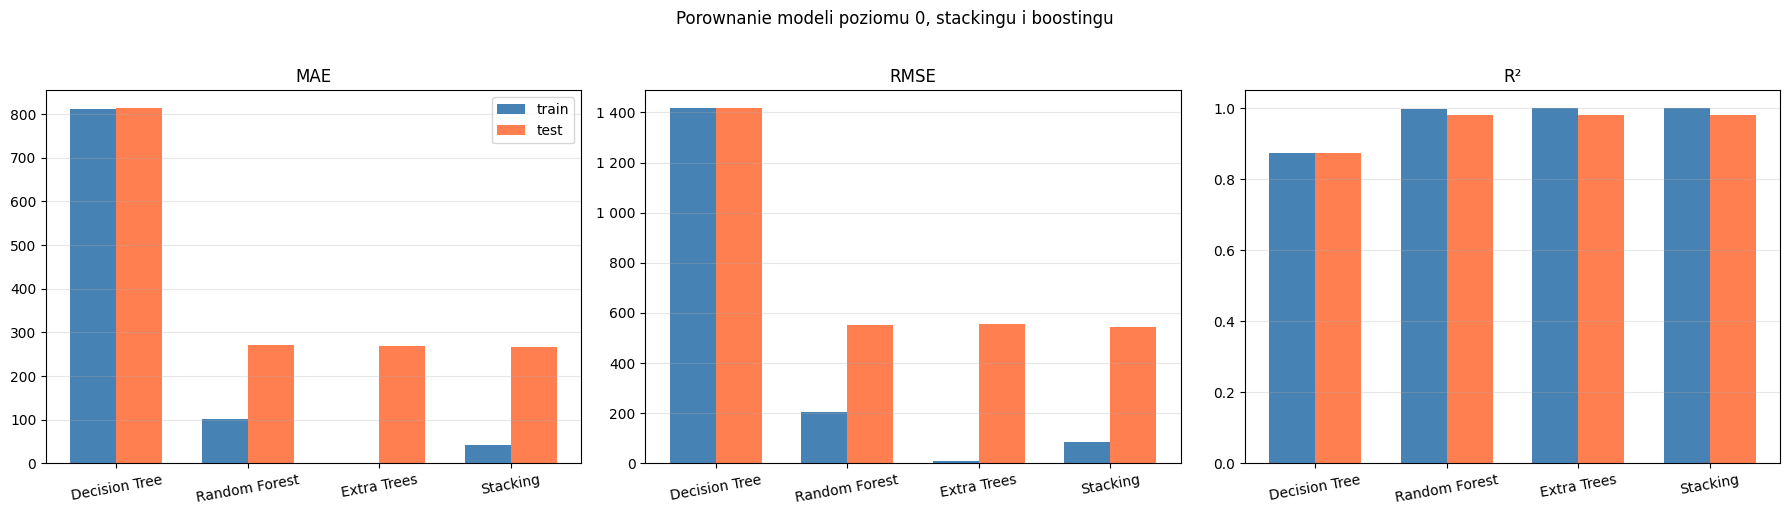

In [21]:
plot_stacking_models_report(stacking_experiment)

Komentarz: 
- pierwszy wykres pozwala bezpośrednio ocenić, czy zastosowanie meta-modelu przyniosło korzyść względem modeli bazowych. Widać, że Stacking osiągnął najlepsze wyniki na zbiorze testowym, mimo że nie był modelem najlepiej dopasowanym do danych treningowych. Sugeruje to, że meta-model skutecznie połączył informacje pochodzące od modeli poziomu 0 i lepiej generalizował na nowych danych.

- Stacking osiągnął najniższą wartość błędu na zbiorze testowym (RMSE = 543.33), wyprzedzając zarówno Random Forest (550.57), jak i Extra Trees (555.31). Przewaga nad pojedynczym Decision Tree (1416.77) była natomiast bardzo wyraźna, co potwierdza skuteczność metod zespołowych w zadaniach regresyjnych. Wyniki wskazują, że połączenie predykcji wielu modeli pozwoliło uzyskać lepszą jakość predykcji niż wykorzystanie któregokolwiek z nich osobno.

In [22]:
display_stacking_vs_boosting(stacking_experiment)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Stacking,42.2648,265.4705,83.6980,543.3274,0.9996,0.9814
1,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


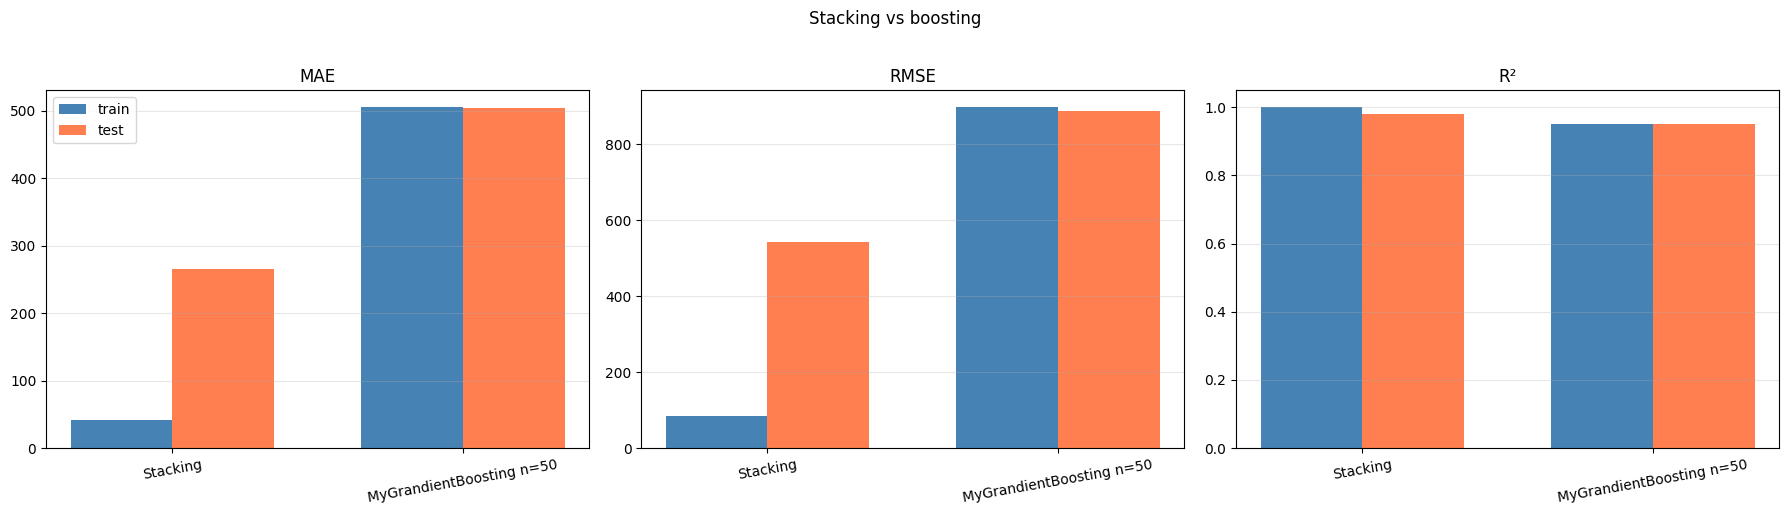

In [23]:
plot_stacking_vs_boosting_report(stacking_experiment)

Komentarz: 
- tabela zawierająca jedynie wyniki Stacking i Boosting pokazuje wyraźną przewagę stackingu. Różnica w wartoci RMSE wynosi około 344 punktów (543.33 vs 887.82), a współczynnik determinacji R² wzrasta z 0.9504 do 0.9814. Oznacza to, że stacking znacznie lepiej odwzorowuje zależności występujące w danych i generuje dokładniejsze predykcje.

- Na bezpośrednim wykresie porównawczym przewaga stackingu jest dobrze widoczna. Chociaż Boosting` znacząco poprawia wyniki względem pojedynczego drzewa decyzyjnego, w analizowanym problemie nie osiąga jakości predykcji porównywalnej ze stackingiem. Sugeruje to, że połączenie predykcji kilku zróżnicowanych modeli okazało się skuteczniejsze niż sekwencyjne korygowanie błędów pojedynczego modelu.


In [24]:
display_stacking_diagnostics(stacking_experiment)

,Model,Meta coefficient,Test MAE,Test RMSE,Test R2
0,Decision Tree,0.0091,813.9943,1416.7711,0.8737
1,Random Forest,0.3797,270.1552,550.5685,0.9809
2,Extra Trees,0.6126,269.0765,555.3080,0.9806


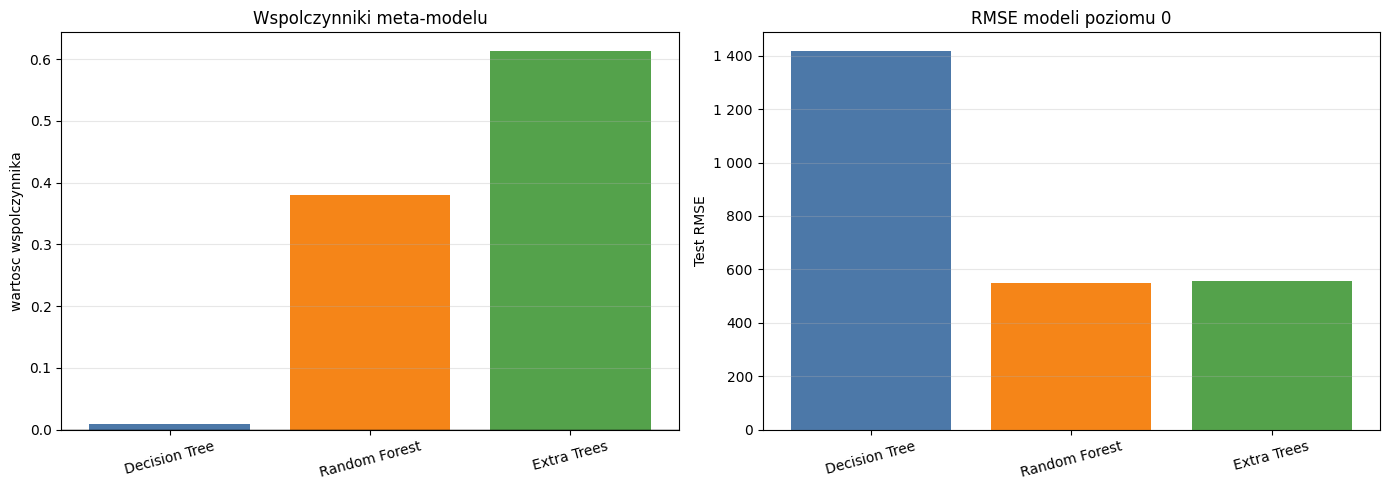

In [25]:
plot_stacking_diagnostics_report(stacking_experiment)

Komentarz: wykres i tabela diagnostyczna pokazują sposób działania meta-modelu. Największą wagę otrzymał Extra Trees (0.6126), następnie Random Forest (0.3797), natomiast wpływ pojedynczego `Decision Tree okazał się znikomy (0.0091). Oznacza to, że meta-model nauczył się przypisywać większe znaczenie modelom osiągającym lepsze wyniki i niemal całkowicie ignorować najsłabszy regresor. W efekcie główny ciężar predykcji został przeniesiony na dwa silne modele zespołowe, które dostarczały najbardziej wartościowych informacji.


## Zadanie na 4.5 Boosting

Porównuję pojedyncze DecisionTreeRegressor z moją uproszczoną implementacją boostingu dla zbioru diamonds. W tej implementacji pierwszy model startuje od przewidywania średniej wartości zmiennej docelowej, a każde kolejne drzewo uczy się przewidywać reszty, czyli błędy popełnione przez dotychczasowy model. Końcowa predykcja jest sumą kolejnych poprawek przemnożonych przez learning_rate.

Dla obu modeli pokazuję metryki MAE, RMSE i R², a dla boostingu dodatkowo badam wpływ n_estimators na wyniki train/test. Ta sekcja wykorzystuje ten sam problem regresyjny co stacking, dzięki czemu oba podejścia można później sensownie zestawić jakościowo.

In [26]:
boosting_experiment = BoostingComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)

In [27]:
display_boosting_results(boosting_experiment)

,n_estimators,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,1,2747.9463,2732.1511,3643.7001,3638.2202,0.1660,0.1673
1,5,1890.8505,1875.5092,2608.8779,2593.6102,0.5725,0.5768
2,10,1282.5532,1269.5350,1864.4901,1846.5305,0.7816,0.7855
3,20,793.1447,788.1514,1271.6379,1261.3961,0.8984,0.8999
4,30,650.9406,648.4021,1089.2266,1079.5795,0.9255,0.9267
5,50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


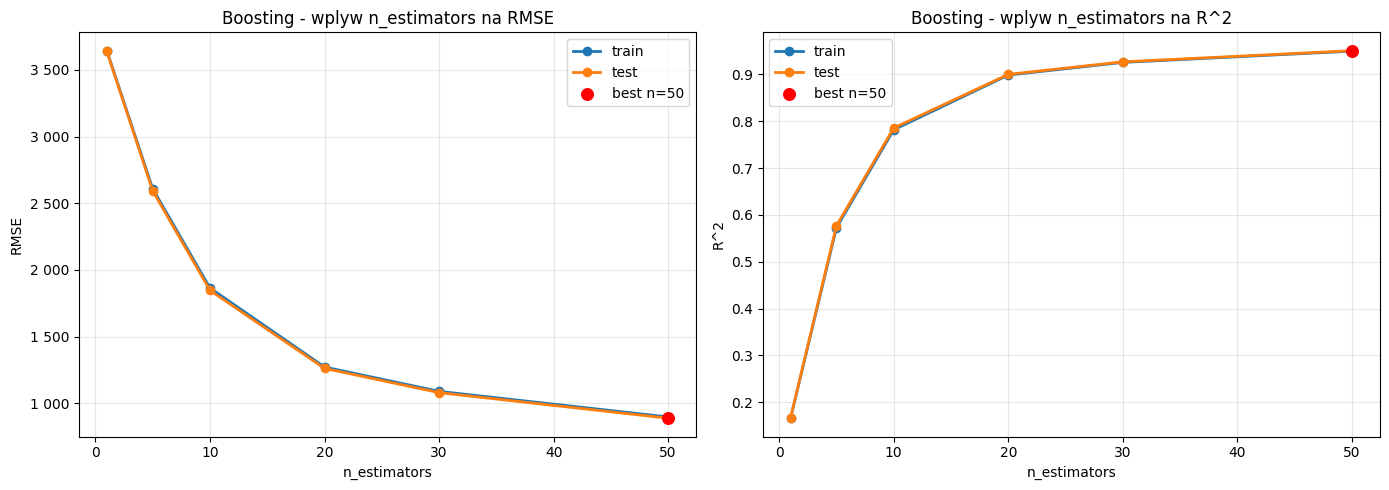

In [28]:
plot_boosting_n_estimators_report(boosting_experiment)

Komentarz: 
- tabela wyników boostingu pokazuje systematyczną poprawę jakości modelu wraz ze wzrostem liczby drzew. Wraz ze zwiększaniem parametru n_estimators wartość RMSE maleje, a współczynnik R² rośnie, co świadczy o coraz lepszym dopasowaniu modelu do danych. Najlepsze wyniki w badanym zakresie uzyskano dla n_estimators = 50.

- Wykres zależności metryk od liczby estymatorów potwierdza ten trend. Każda kolejna grupa drzew poprawia jakość predykcji, a w analizowanym zakresie nie obserwuje się jeszcze pogorszenia wyników na zbiorze testowym. Oznacza to, że model nadal korzysta z dodawania kolejnych estymatorów i nie osiągnął jeszcze punktu, w którym dalsze zwiększanie ich liczby prowadziłoby do przeuczenia.

In [30]:
display_boosting_comparison(boosting_experiment)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,DecisionTreeRegressor depth=3,811.2760,813.9943,1417.1171,1416.7711,0.8739,0.8737
1,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


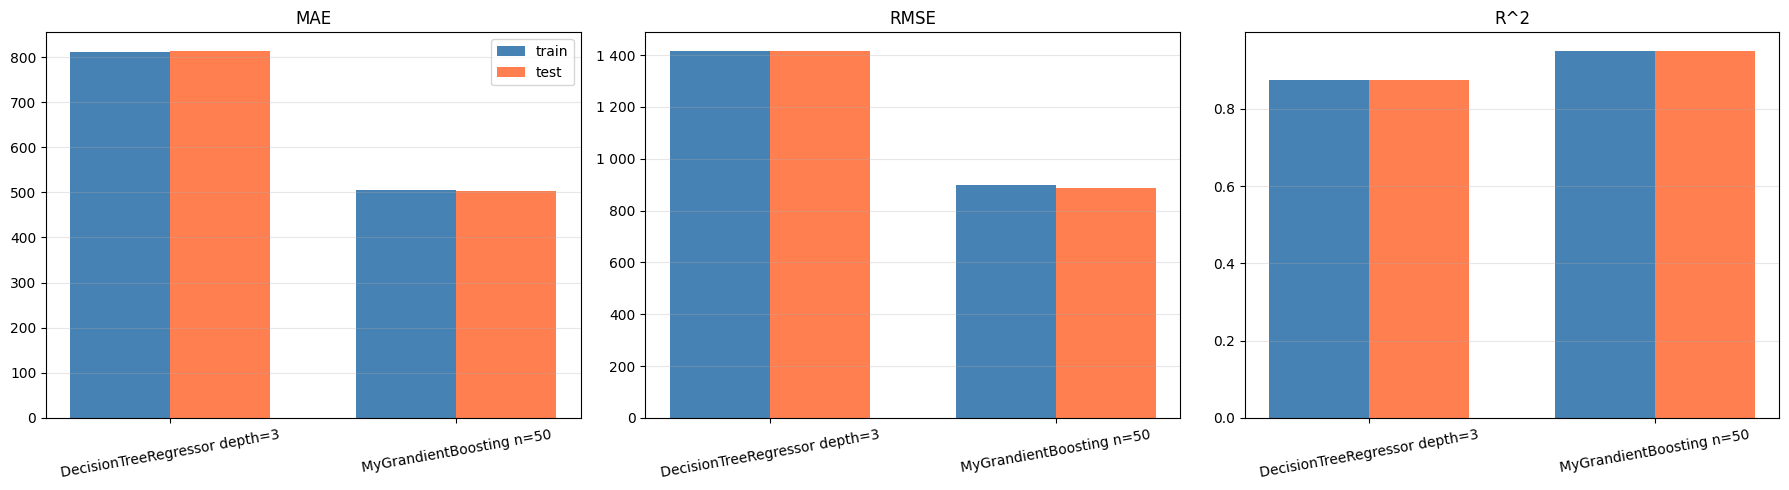

In [31]:
plot_boosting_comparison_report(boosting_experiment)

Komentarz: na wykresie różnica między jednym drzewem a boostingiem jest bardzo czytelna. Zysk dotyczy wszystkich metryk jednocześnie, więc nie jest to poprawa przypadkowa, tylko stabilna.

#### Wniosek
Na zbiorze diamonds boosting wyraźnie poprawił wyniki względem pojedynczego DecisionTreeRegressor. Najlepsza konfiguracja w badanym zakresie to n_estimators = 50, dla której model osiągnął test MAE = 503.53, test RMSE = 887.82 oraz test R² = 0.9504.

Dla porównania pojedyncze drzewo o tej samej głębokości (max_depth = 3) uzyskało test MAE = 813.99, test RMSE = 1416.77 oraz test R² = 0.8737. Wykres po n_estimators pokazuje, że wraz z dodawaniem kolejnych drzew błąd systematycznie maleje, a współczynnik R² rośnie, więc uproszczony boosting rzeczywiście uczy się coraz lepszego przybliżenia ceny

## Zadanie na 5.0 Mixture of Experts

W tej części wykorzystuję system Mixture of Experts zgodny z logiką zadania. Najpierw KMeans dzieli przestrzeń cech na 3 klastry, potem bramka RandomForestClassifier uczy się przewidywać, do którego klastra należy nowy rekord, a następnie do predykcji wykorzystywany jest tylko ekspert przypisany do tego klastra.

Eksperci nie są tu identyczni: dla kolejnych klastrów używam odpowiednio Ridge, RandomForestRegressor oraz GradientBoostingRegressor. Dzięki temu system ma bardziej zróżnicowaną architekturę niż jeden globalny model i można sprawdzić, czy specjalizacja ekspertów daje przewagę jakościową.

In [32]:
mixture_of_experts_experiment = MixtureOfExpertsComparison().compare(
    X_train=X_train_diamonds,
    X_test=X_test_diamonds,
    y_train=y_train_diamonds,
    y_test=y_test_diamonds,
)

In [33]:
display_mixture_cluster_summary(mixture_of_experts_experiment)

,cluster,count,mean_price,mean_carat,mean_depth,mean_table,mean_x,mean_y,mean_z,expert_model
0,0,13117,1430.0618,-0.6710,-0.0712,0.3811,-0.6934,-0.6761,-0.6861,Ridge
1,1,12663,1702.9626,-0.6610,-0.0248,-0.7376,-0.6732,-0.6478,-0.6549,RandomForestRegressor
2,2,17372,7464.5502,0.9885,0.0718,0.2500,1.0143,0.9827,0.9954,GradientBoostingRegressor


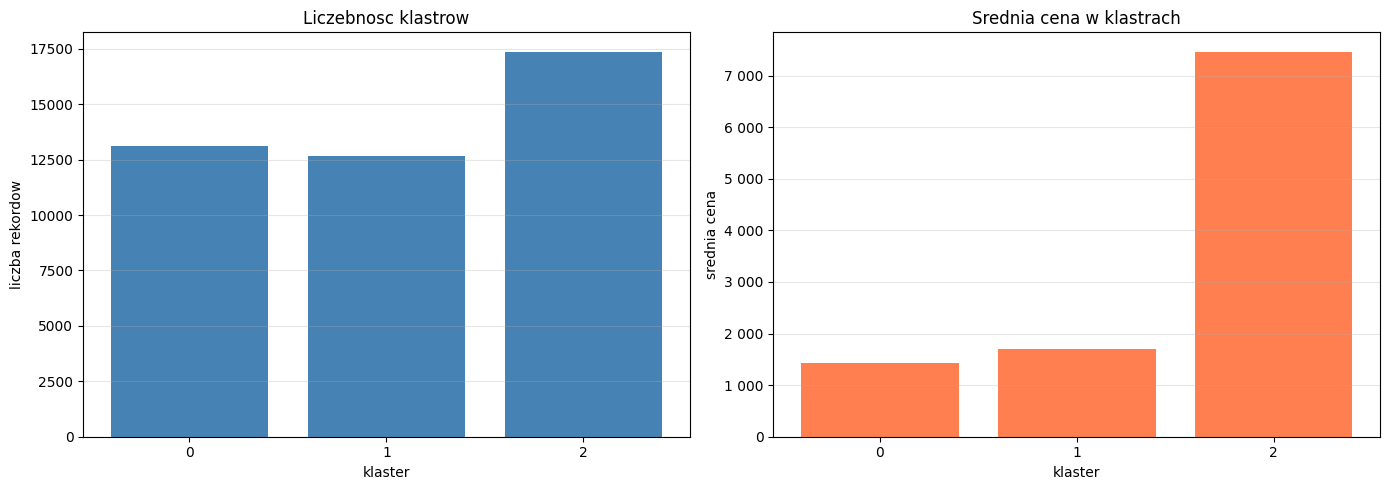

In [34]:
plot_mixture_clusters_report(mixture_of_experts_experiment)

Komentarz: 
- analiza klastrów pokazuje, że algorytm KMeans podzielił dane na trzy wyraźnie różniące się segmenty rynku diamentów. Dwa klastry obejmują tańsze kamienie (mean_price = 1430.06 oraz 1702.96), natomiast trzeci skupia znacznie droższe diamenty (7464.55). Każdemu z klastrów został przypisany inny model ekspercki, dostosowany do charakterystyki danej grupy.

- Wizualizacja klastrów potwierdza, że najbardziej odrębną grupę stanowią duże i drogie diamenty obsługiwane przez GradientBoostingRegressor. Pozostałe dwa klastry są do siebie bardziej zbliżone pod względem cen i cech, dlatego korzyść z zastosowania różnych ekspertów jest w ich przypadku mniej wyraźna. Mimo to podział danych na segmenty pozwala ekspertom specjalizować się w różnych obszarach przestrzeni cech, co stanowi podstawową ideę architektury Mixture of Experts.

In [35]:
display_mixture_global_comparison(mixture_of_experts_experiment)

,Model,MAE,MSE,RMSE,R2
0,Mixture of Experts,367.9360,463796.0756,681.0258,0.9708
1,Global Random Forest,270.1552,303125.6549,550.5685,0.9809


In [36]:
display_mixture_model_comparison(mixture_of_experts_experiment)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Mixture of Experts,338.9032,367.9360,651.6653,681.0258,0.9733,0.9708
1,Global Random Forest,100.9854,270.1552,206.4245,550.5685,0.9973,0.9809
2,MyGrandientBoosting n=50,504.7587,503.5323,897.0248,887.8224,0.9495,0.9504


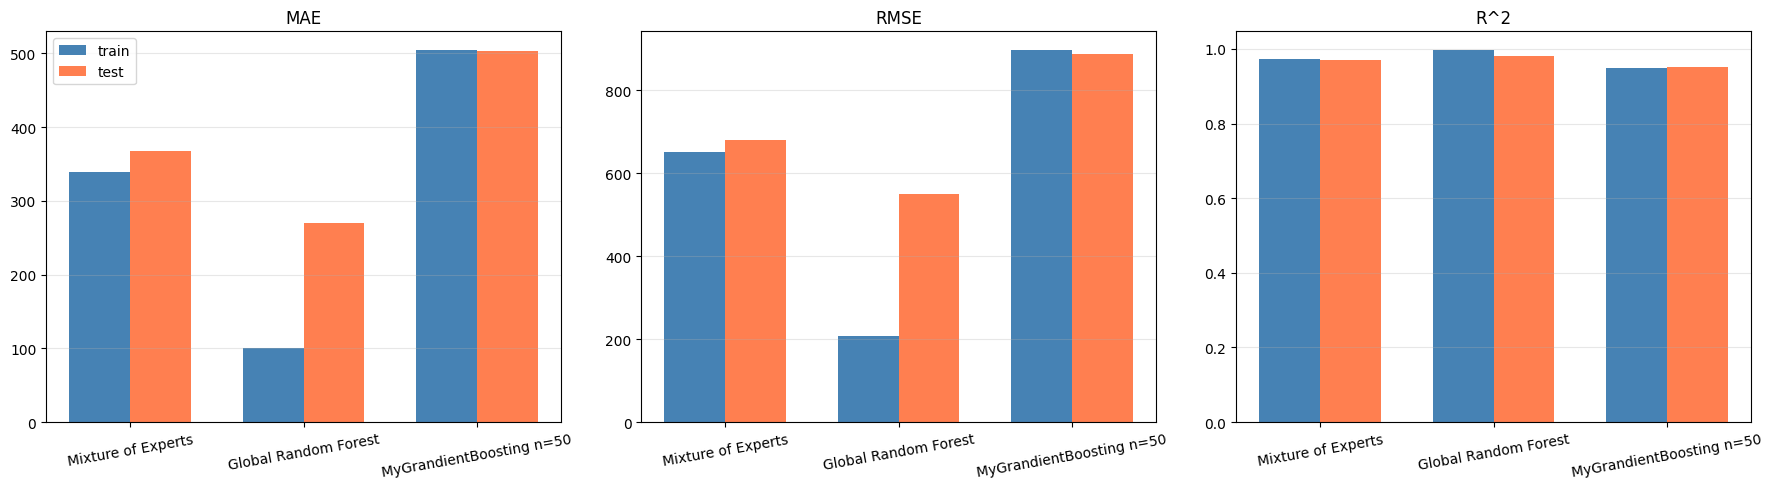

In [37]:
plot_mixture_model_comparison_report(mixture_of_experts_experiment)

Komentarz: 
- porównanie z globalnym Random Forest pokazuje, że po zastosowaniu ekspertów zgodnych z założeniami zadania model Mixture of Experts nie osiągnął już tak dobrych wyników jak wcześniejsze wersje. MoE uzyskał RMSE = 681.03, podczas gdy globalny Random Forest osiągnął RMSE = 550.57, co oznacza, że prostszy model globalny lepiej radził sobie z predykcją na całym zbiorze danych.

- Jednocześnie Mixture of Experts nadal wyraźnie przewyższa boosting (RMSE = 681.03 vs 887.82), co sugeruje, że podział danych na klastry i specjalizacja ekspertów przynoszą korzyści. Wyniki wskazują jednak, że zastosowany zestaw ekspertów nie był optymalny jakościowo. Ostatecznie MoE zajmuje pozycję pomiędzy boostingiem a globalnym Random Forest – poprawia wyniki względem prostszego modelu zespołowego, ale nie osiąga jakości najlepszego modelu globalnego.


#### Wniosek
KMeans podzielił diamenty na trzy sensowne regiony, a do każdego z nich został przypisany inny ekspert: Ridge, RandomForestRegressor albo GradientBoostingRegressor. Najdroższy klaster miał średnią cenę około 7464.55, a dwa pozostałe około 1430.06 i 1702.96, więc podział przestrzeni nie był losowy i rzeczywiście rozdzielał różne typy rekordów.

W porównaniu testowym Mixture of Experts osiągnął MAE = 367.94, RMSE = 681.03 i R² = 0.9708. Globalny RandomForestRegressor uzyskał wyraźnie lepsze MAE = 270.16, RMSE = 550.57 i R² = 0.9809, więc w tym wariancie MoE przegrywa z prostszym modelem globalnym. Z kolei względem MyGradientBoosting n=50 przewaga MoE nadal jest czytelna, bo boosting osiągnął RMSE = 887.82 i R² = 0.9504.

Korzyść architektoniczna MoE pozostaje taka sama: dla pojedynczego rekordu uruchamiany jest tylko jeden ekspert wskazany przez bramkę, a nie jeden globalny model dla całej przestrzeni. W tym eksperymencie taki układ okazał się jednak bardziej interesujący koncepcyjnie niż optymalny jakościowo, bo najlepszy wynik nadal dawał globalny las losowy.

## Podsumowanie końcowe
Na wykresie klasyfikacyjnym pokazuję tylko modele klasyfikacyjne: Decision Tree, Random Forest i Bagging. Nie umieszczam tam Lasso i Ridge, ponieważ w tym raporcie były one badane na problemie regresyjnym diamonds, więc nie mają sensownych metryk Accuracy, Precision, Recall i F1-score.

W drugim wykresie zestawiam Stacking, MyGradientBoosting i Mixture of Experts na wspólnym problemie regresyjnym. Wykres pokazuje bezpośrednio wartości Test MAE, Test RMSE i Test R², dzięki czemu porównanie nie wymaga dodatkowej normalizacji i łatwo wskazać najlepszy model w każdej metryce.

In [38]:
display_final_classification_summary(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.7289,0.7317,0.7289,0.7302
1,Random Forest,0.7779,0.7655,0.7779,0.7688
2,Bagging,0.7779,0.7670,0.7779,0.7704


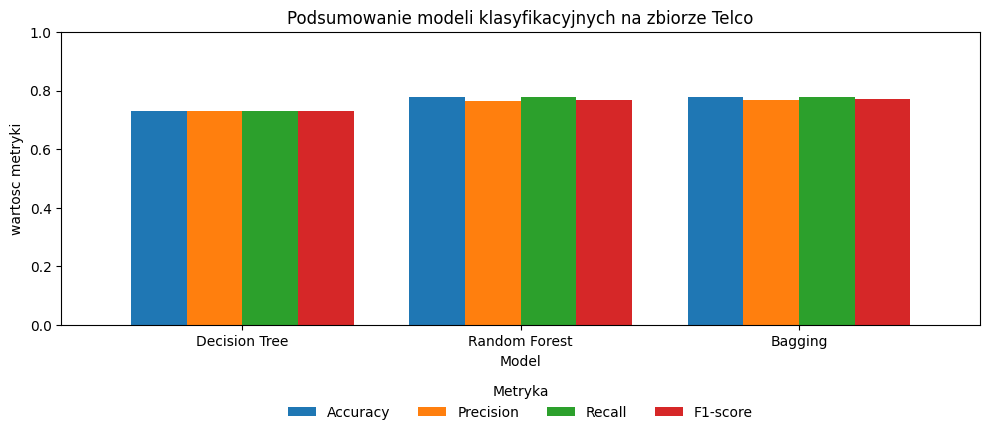

In [39]:
plot_final_classification_summary_report(comparison_df)

Komentarz: 
- końcowa tabeli klasyfikacyjnej i wykresu zbierającego najważniejsze modele w jednym miejscu i potwierdza wcześniejszy obraz. Minimalnie najlepszy jest Random Forest, ale przewaga nad Bagging jest niewielka, więc oba rozwiązania można uznać za bardzo mocne

In [40]:
display_final_regression_summary(stacking_experiment, mixture_of_experts_experiment)

,Model,Test MAE,Test RMSE,Test R2
0,Stacking,265.4705,543.3274,0.9814
1,MyGrandientBoosting n=50,503.5323,887.8224,0.9504
2,Mixture of Experts,367.9360,681.0258,0.9708


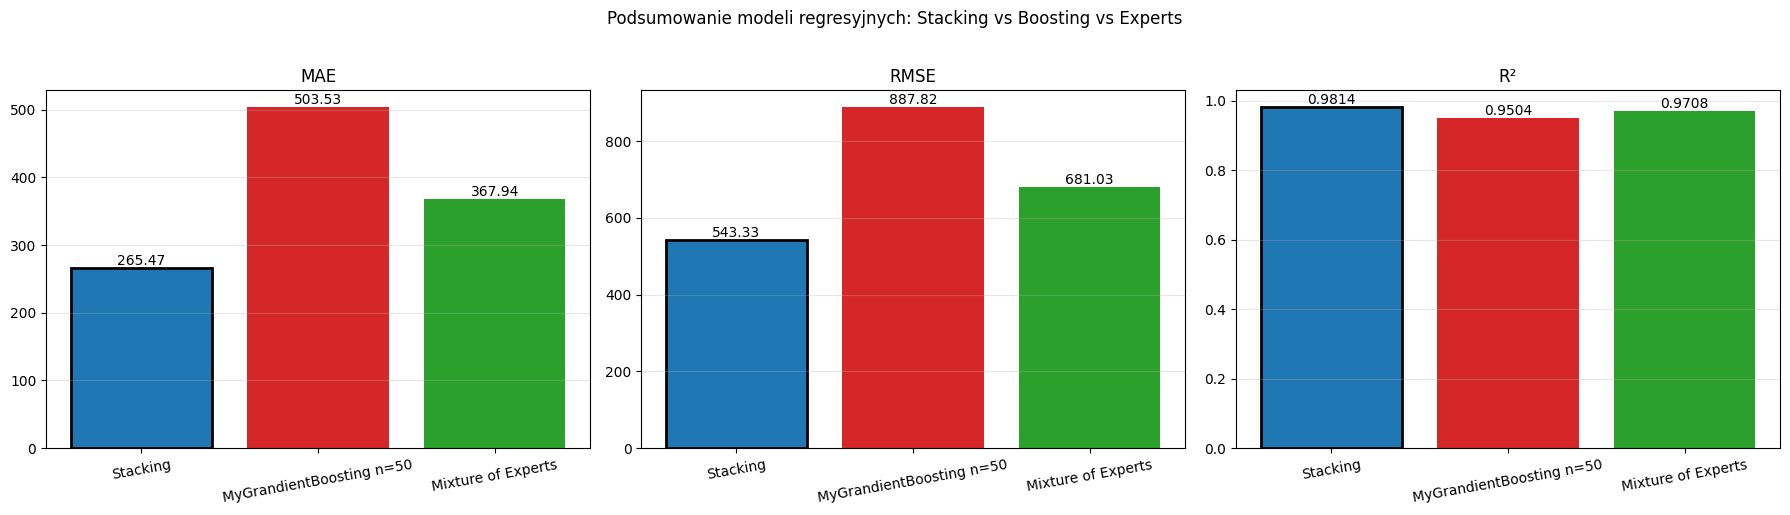

In [41]:
plot_final_regression_summary_report(stacking_experiment, mixture_of_experts_experiment)

Komentarz: końcowy wykres regresyjny podsumowuje aktualny obraz po urealnieniu MoE do modeli sugerowanych w zadaniu. Najlepiej wypada Stacking, MoE pozostaje lepszy od boostingu, ale nie jest już kandydatem na zwycięzcę całej części regresyjnej.

#### Wniosek
W części klasyfikacyjnej najlepszy wynik końcowy uzyskał Random Forest. Na zbiorze testowym osiągnął Accuracy = 0.7779, Precision = 0.7655, Recall = 0.7779 oraz F1-score = 0.7688, czyli minimalnie wyprzedził Bagging, a wyraźnie pokonał pojedyncze Decision Tree.

W części regresyjnej najlepszy okazał się Stacking, który osiągnął test MAE = 265.47, test RMSE = 543.33 oraz test R² = 0.9814. Mixture of Experts po przejściu na ekspertów zgodnych z treścią zadania osiągnął RMSE = 681.03 i R² = 0.9708, więc pozostał lepszy od MyGradientBoosting n=50 (RMSE = 887.82, R² = 0.9504), ale wyraźnie ustąpił stackingowi. Oznacza to, że na zbiorze diamonds najlepiej zadziałało łączenie kilku silnych regresorów przez meta-model, a w klasyfikacji Telco najmocniejszy okazał się las losowy.